In [1]:
import numpy as np
from sim_library.simulation import simulate_pulses_single_atom, simulate_pulses_single_atom_analyt
from sim_library.sequences import  RR3_gate, UpPulse, DownPulse, PulseSequence, swap34_gate, exchange10_gate, RR3_adjMDFE_500kHz, RR3_phasecomp_500kHz
from sim_library.plotting import  display_table_compare
from scipy.constants import hbar, pi
from sim_library.constants import k_eff, dR, m, omega_eg, kb
import matplotlib.pyplot as plt

### Fidelity

In [19]:
# rabi_freq = 2*pi*1e5
# rabi_time = 2*pi/rabi_freq

# omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

time_steps = 1

RR3_opt = RR3_phasecomp_500kHz(time_steps=time_steps, detuning=0)

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=(8,len(basis)), dtype=np.complex128)
target = np.zeros(shape=(8,len(basis)), dtype=np.complex128)

initial_state[0,8] = 1
initial_state[1, 10] = 1
initial_state[2, 12] = 1
initial_state[3, 14] = 1
initial_state[4, 16] = 1
initial_state[5, 18] = 1
initial_state[6, 20] = 1
initial_state[7, 22] = 1

target[0,8] = 1
target[1,9] = 1
target[2,10] = 1
target[3,11] = 1
target[4,16] = 1
target[5,17] = 1
target[6,18] = 1
target[7,19] = 1


# rabi_freqs = 2*pi*np.logspace(5, 9, 100)
rabi_freqs = np.linspace(2*pi*0.5e6,2*pi*0.5e6,1)
fidelities = np.zeros((8,len(rabi_freqs)))

for j in range(8):
    for i, rabi in enumerate(rabi_freqs):

        RR3 = RR3_gate(rabi_freq=rabi, time_steps=time_steps)

        wave_func, times = simulate_pulses_single_atom_analyt(pulse_seq= RR3_opt, basis= basis, initial_state=initial_state[j,:], d_shift=0)

        final = wave_func[-1,:]
        final = final/np.linalg.norm(final)

        fidelity = np.abs(np.vdot(target[j,:],final))**2
        fidelities[j,i] = fidelity

# fig, ax = plt.subplots()

# print(rabi_freqs[])
avg_fids = np.mean(fidelities[4:], axis=0)
print(avg_fids)
print(fidelities[4:].transpose())

[0.85568461]
[[0.96746099 0.98590663 0.85923549 0.61013534]]


### Detuning scan

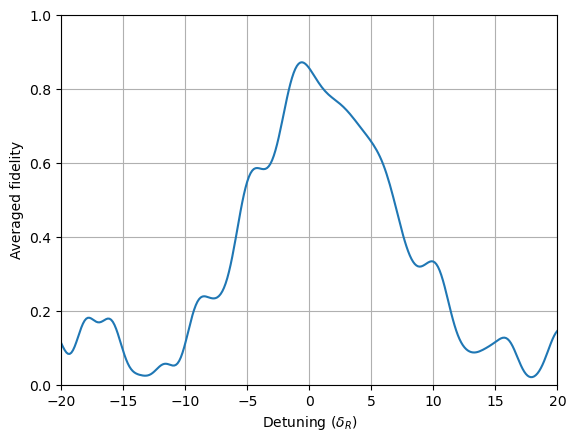

In [34]:
rabi_freq = 2*pi*1e5
rabi_time = 2*pi/rabi_freq

# omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

time_steps = 1



p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=(4,len(basis)), dtype=np.complex128)
target = np.zeros(shape=(4,len(basis)), dtype=np.complex128)

initial_state[0, 16] = 1
initial_state[1, 18] = 1
initial_state[2, 20] = 1
initial_state[3, 22] = 1

target[0,16] = 1
target[1,17] = 1
target[2,18] = 1
target[3,19] = 1

detunings = np.linspace(-20*dR,20*dR, 300)

fidelities = np.zeros((4,len(detunings)))

for j in range(4):
    for i, det in enumerate(detunings):
        
        RR3_opt = RR3_phasecomp_500kHz(time_steps=time_steps, detuning=det)

        wave_func, times = simulate_pulses_single_atom_analyt(pulse_seq= RR3_opt, basis= basis, initial_state=initial_state[j,:], d_shift=0)

        final = wave_func[-1,:]
        final = final/np.linalg.norm(final)

        fidelity = np.abs(np.vdot(target[j,:],final))**2
        fidelities[j,i] = fidelity

# fig, ax = plt.subplots()

# print(rabi_freqs[])
avg_fids = np.mean(fidelities, axis=0)

fig, ax = plt.subplots()
ax.plot(detunings/dR, avg_fids)
ax.set_ylim(0,1)
ax.set_xlim(detunings[0]/dR, detunings[-1]/dR)
ax.set_ylabel('Averaged fidelity')
ax.set_xlabel(r'Detuning ($\delta_R$)')
ax.grid()

### Misc.

In [7]:
dur = 0
n = 0
for p in RR3.pulses:
    if p.type != 'free':
        dur += p.duration
        n+=1
print(dur)

3.4999999999999974e-06


In [ ]:
rabi_freq = 2*pi*1e9
# rabi_time = 2*pi/rabi_freq

# omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

time_steps = 1

RR3 = RR3_gate(rabi_freq=rabi_freq, time_steps=time_steps)

dur = 0
n = 0
for p in RR3.pulses:
    if p.type != 'free':
        dur += p.duration
        n+=1

print( dur/(pi/rabi_freq))
print(n)
prevp = UpPulse(laser_det=np.array([1]),phase=np.array([1]), rabi_freq=np.array([1]), duration=1)
for p in RR3.pulses:
    if prevp.type == p.type and p.type != 'free':
        print(prevp.phase/ (2*pi), prevp.duration*1e9)
        print(p.phase/ (2*pi), p.duration*1e9)
        print('____')
    prevp = p

35.0
44
[0.] 0.25
[0.] 0.25
____


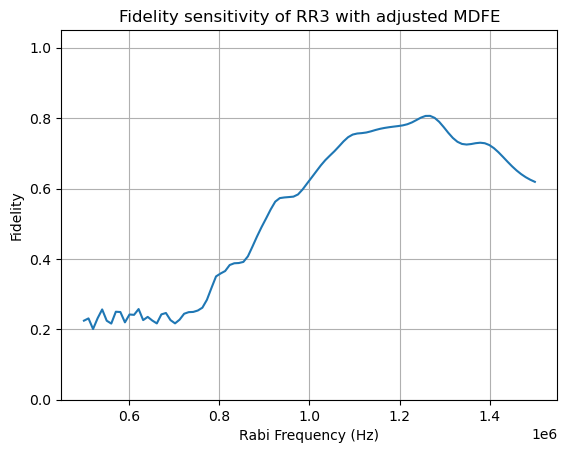

In [ ]:
avg_fids = np.mean(fidelities, axis=0)

plt.plot(rabi_freqs/(2*pi), avg_fids)
plt.grid(axis='both')
# plt.xlim(0.5e6,1.5e6)
# plt.xlim(1e5, 1e9)
plt.ylim(0,1.05)
plt.ylabel('Fidelity')
plt.xlabel('Rabi Frequency (Hz)')
plt.title(rf'Fidelity sensitivity of RR3 with adjusted MDFE')
plt.title

plt.show()
# print(fidelities)

In [ ]:
title_text = [r'|000,p=-8\rangle', r'|010,p=-6\rangle', r'|100,p=-4\rangle', r'|110,p=-2\rangle', r'|000,p=0\rangle', r'|010,p=2\rangle', r'|100,p=4\rangle', r'|110,p=6\rangle']
for i in range(8):
    plt.semilogx(rabi_freqs/(2*pi), fidelities[i])
    plt.grid(axis='both')
    plt.xlim(1e5,1e9)
    plt.ylim(0,1.05)
    plt.ylabel('Fidelity')
    plt.xlabel('Rabi Frequency (Hz)')
    plt.title(rf'Population Fidelity of RR3 with Rectangular pulses ($\psi_{{init}}={title_text[i]}$)')
    plt.title
    plt.show()
    # print(fidelities)


In [43]:
initial_state = np.zeros(shape=(3,5), dtype=np.complex128)
print(initial_state)
print(initial_state[0,:])

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]
[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]


In [10]:
rabi_freq = 2*pi*1e9
rabi_time = 2*pi/rabi_freq

# omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

time_steps = 1

# RR3 = RR3short2_gate(rabi_freq=rabi_freq, time_steps=time_steps)

exgate = exchange10_gate(rabi_freq=rabi_freq, time_steps=time_steps)

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
# initial_state[15] = 1
initial_state[16] = 1
# initial_state[17] = 0
# initial_state[18] = -2
# initial_state[19] = 0
# initial_state[20] = 3j
# initial_state[21] = 0
# initial_state[22] = -4j                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
# initial_state[23] = 0
# initial_state[24] = 0

initial_state = initial_state/ np.linalg.norm(initial_state)

target = np.zeros(shape=len(basis), dtype=np.complex128)

target[16] = 1
# target[17] = -2
# target[18] = 3j
# target[19] = -4j


target = target/ np.linalg.norm(target)

wave_func, times = simulate_pulses_single_atom(pulse_seq= exgate, basis= basis, initial_state=initial_state, d_shift=(6*hbar*k_eff)*k_eff/m)

final = wave_func[-1,:]
final = final/np.linalg.norm(final)

fidelity = np.sum(np.abs(target)*np.abs(final))**2

print(fidelity)



  
display_table_compare(basis=basis, init_state=initial_state, final_state=wave_func[-1,:])

2.138395556754833e-06
+---------+---------------------+---------------+---------------------+-------------------+-----------------+
|   Index |   Momentum (hbar*k) |   Initial Psi |           Final Psi |   Initial |Psi|^2 |   Final |Psi|^2 |
+=========+=====================+===============+=====================+===================+=================+
|       0 |                 -16 |       0j|000> |             0j|000> |                 0 |               0 |
+---------+---------------------+---------------+---------------------+-------------------+-----------------+
|       1 |                 -15 |       0j|001> |             0j|001> |                 0 |               0 |
+---------+---------------------+---------------+---------------------+-------------------+-----------------+
|       2 |                 -14 |       0j|010> |             0j|010> |                 0 |               0 |
+---------+---------------------+---------------+---------------------+-------------------+-------

In [42]:
rabi_freq = 2*pi*1e9
rabi_time = 2*pi/rabi_freq

# omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

time_steps = 1

RR3 = RR3short2_gate(rabi_freq=rabi, time_steps=time_steps)

RR3short = PulseSequence()

prevp = UpPulse(laser_det=np.array([1]),phase=np.array([1]), rabi_freq=np.array([1]), duration=1)
for p in RR3.pulses:
    if prevp.type == p.type and p.type != 'free':
        if p.duration/(rabi_time) > 0.45:
            if p.type == 'up':
                RR3short.add_pulses(UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2))
            else:
                RR3short.add_pulses(DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2))
        else:
            if p.type == 'up':
                RR3short.add_pulses(UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, pi), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4))
            else:
                RR3short.add_pulses(DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, pi), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4))
    else:

        RR3short.add_pulses(prevp)
    prevp = p

TypeError: Only Pulse or PulseSequence objects can be added.